In [1]:
from google.colab import files

uploaded = files.upload()



Saving online_courses_uses.csv to online_courses_uses.csv


In [2]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())


   Course_ID Course_Name      Category  Duration (hours)  Enrolled_Students  \
0          1    Course_1  Office Tools                21               4217   
1          2    Course_2  Office Tools                57               4238   
2          3    Course_3    Technology                52               2700   
3          4    Course_4  Office Tools                69               4308   
4          5    Course_5    Technology                43               4792   

   Completion_Rate (%)           Platform   Price ($)  Rating (out of 5)  
0            50.646827           Coursera   38.797425           4.811252  
1            82.240240                edX  160.650991           3.829329  
2            55.729028  LinkedIn Learning  123.503781           4.851950  
3            58.664729  LinkedIn Learning  116.775704           3.913732  
4            62.598147              Udemy   96.246696           4.921968  


In [3]:
print(df.columns.tolist())


['Course_ID', 'Course_Name', 'Category', 'Duration (hours)', 'Enrolled_Students', 'Completion_Rate (%)', 'Platform', 'Price ($)', 'Rating (out of 5)']


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())



(10000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Course_ID            10000 non-null  int64  
 1   Course_Name          10000 non-null  object 
 2   Category             10000 non-null  object 
 3   Duration (hours)     10000 non-null  int64  
 4   Enrolled_Students    10000 non-null  int64  
 5   Completion_Rate (%)  10000 non-null  float64
 6   Platform             10000 non-null  object 
 7   Price ($)            10000 non-null  float64
 8   Rating (out of 5)    10000 non-null  float64
dtypes: float64(3), int64(3), object(3)
memory usage: 703.3+ KB
None
Course_ID              0
Course_Name            0
Category               0
Duration (hours)       0
Enrolled_Students      0
Completion_Rate (%)    0
Platform               0
Price ($)              0
Rating (out of 5)      0
dtype: int64


In [5]:
# Find the median rating
median_rating = df["Rating (out of 5)"].median()

print("Median Rating:", median_rating)

# Create High_Rating target
df["High_Rating"] = (
    df["Rating (out of 5)"] >= median_rating
).astype(int)

# Display the result
print(df[["Rating (out of 5)", "High_Rating"]].head(10))



Median Rating: 4.002789239114857
   Rating (out of 5)  High_Rating
0           4.811252            1
1           3.829329            0
2           4.851950            1
3           3.913732            0
4           4.921968            1
5           3.252283            0
6           4.101807            1
7           3.088730            0
8           4.498471            1
9           3.341868            0


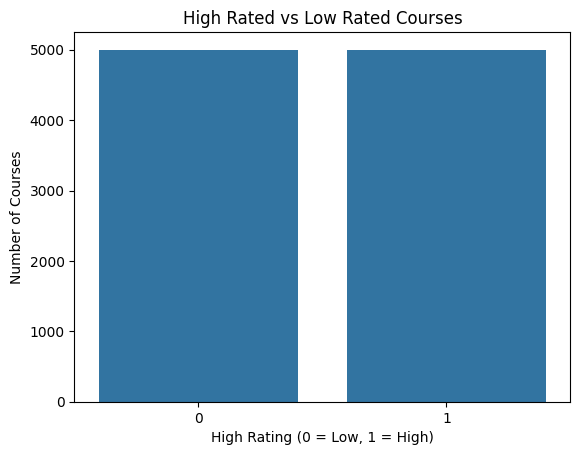

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="High_Rating", data=df)

plt.title("High Rated vs Low Rated Courses")
plt.xlabel("High Rating (0 = Low, 1 = High)")
plt.ylabel("Number of Courses")

plt.show()


   Course_ID Course_Name      Category  Duration (hours)  Enrolled_Students  \
0          1    Course_1  Office Tools                21               4217   
1          2    Course_2  Office Tools                57               4238   
2          3    Course_3    Technology                52               2700   
3          4    Course_4  Office Tools                69               4308   
4          5    Course_5    Technology                43               4792   

   Completion_Rate (%)           Platform   Price ($)  Rating (out of 5)  
0            50.646827           Coursera   38.797425           4.811252  
1            82.240240                edX  160.650991           3.829329  
2            55.729028  LinkedIn Learning  123.503781           4.851950  
3            58.664729  LinkedIn Learning  116.775704           3.913732  
4            62.598147              Udemy   96.246696           4.921968  
(10000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries,

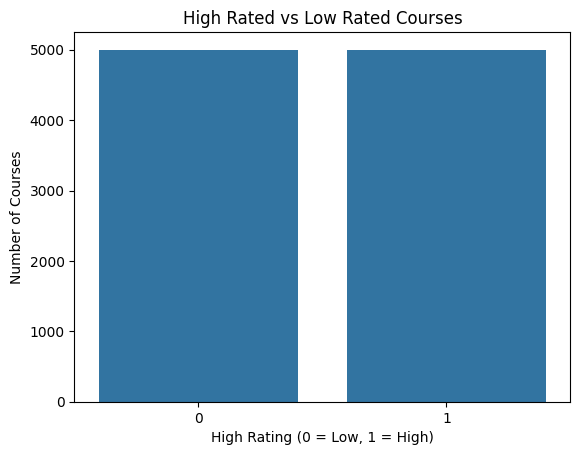

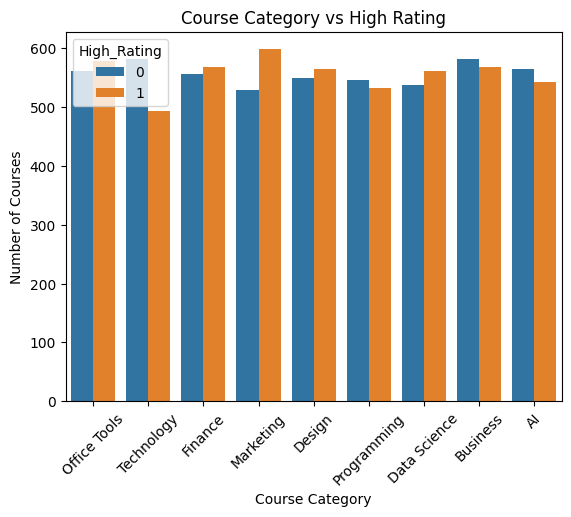

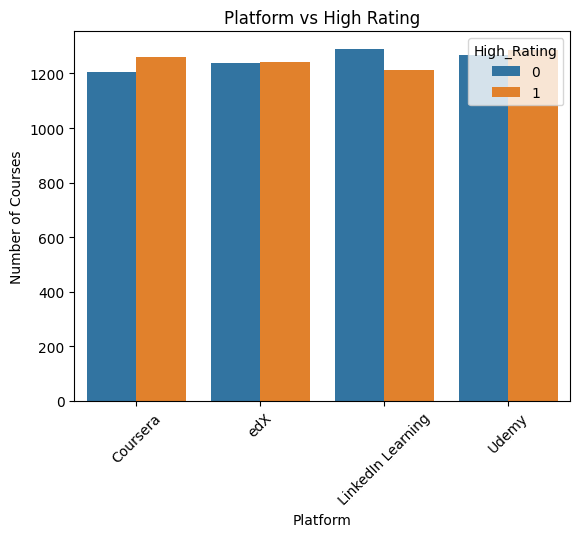

Accuracy: 0.493


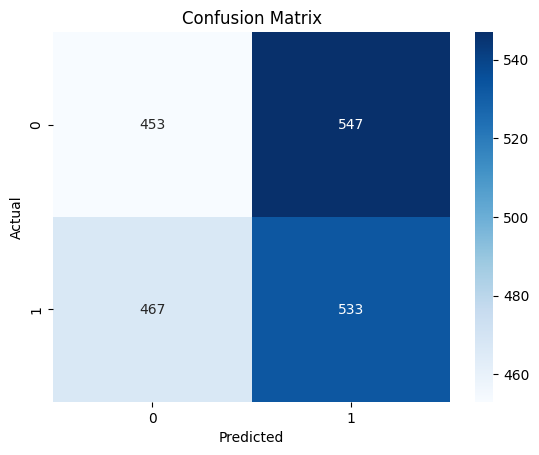

Analysis completed!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


# 1. Load dataset
df = pd.read_csv(list(uploaded.keys())[0])


# 2. Display data
print(df.head())


# 3. Basic information
print(df.shape)
print(df.info())


# 4. Check missing values
print(df.isnull().sum())


# 5. Create target variable - High Rating

median_rating = df["Rating (out of 5)"].median()

df["High_Rating"] = (
    df["Rating (out of 5)"] >= median_rating
).astype(int)

print("Median Rating:", median_rating)


# 6. Visualization - High Rating

sns.countplot(x="High_Rating", data=df)

plt.title("High Rated vs Low Rated Courses")
plt.xlabel("High Rating (0 = Low, 1 = High)")
plt.ylabel("Number of Courses")

plt.show()


# 7. Visualization - Category vs High Rating

sns.countplot(
    x="Category",
    hue="High_Rating",
    data=df
)

plt.title("Course Category vs High Rating")
plt.xlabel("Course Category")
plt.ylabel("Number of Courses")

plt.xticks(rotation=45)

plt.show()


# 8. Visualization - Platform vs High Rating

sns.countplot(
    x="Platform",
    hue="High_Rating",
    data=df
)

plt.title("Platform vs High Rating")
plt.xlabel("Platform")
plt.ylabel("Number of Courses")

plt.xticks(rotation=45)

plt.show()


# 9. Remove Course ID, Course Name and Rating

# Rating is removed because it was used to create High_Rating.
# Course_ID and Course_Name are not useful for prediction.

df = df.drop(
    ["Course_ID", "Course_Name", "Rating (out of 5)"],
    axis=1
)


# 10. Convert categorical data into numbers

df = pd.get_dummies(
    df,
    drop_first=True
)


# 11. Separate features and target

X = df.drop(
    "High_Rating",
    axis=1
)

y = df["High_Rating"]


# 12. Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 13. Train Logistic Regression model

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)


# 14. Make prediction

y_pred = model.predict(X_test)


# 15. Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


# 16. Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# 17. Export DataFrame to Excel

df.to_excel(
    "online_courses_analysis.xlsx",
    index=False
)


# 18. Completion message

print("Analysis completed!")
